In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

pd.set_option("display.max_columns", 1000)

In [2]:
df_state = pd.read_csv("data/raw/hhs_state_timeseries.csv")

1. state
2. date
3. critical_staffing_shortage_today_yes
4. critical_staffing_shortage_today_no
5. critical_staffing_shortage_today_not_reported	
6. critical_staffing_shortage_anticipated_within_week_yes	
7. critical_staffing_shortage_anticipated_within_week_no
9. inpatient_beds	
10. inpatient_beds_coverage	
11. inpatient_beds_used	
12. inpatient_beds_used_coverage	
13. inpatient_beds_used_covid	
14. inpatient_beds_used_covid_coverage

1. Combine critical_staffing_shortage_today_yes, critical_staffing_shortage_today_no
2. Combine critical_staffing_shortage_anticipated_within_week_yes, critical_staffing_shortage_anticipated_within_week_no
2. Join hospital dataset for total bedcount


In [3]:
list(df_state.columns)


['state',
 'date',
 'critical_staffing_shortage_today_yes',
 'critical_staffing_shortage_today_no',
 'critical_staffing_shortage_today_not_reported',
 'critical_staffing_shortage_anticipated_within_week_yes',
 'critical_staffing_shortage_anticipated_within_week_no',
 'critical_staffing_shortage_anticipated_within_week_not_reported',
 'hospital_onset_covid',
 'hospital_onset_covid_coverage',
 'inpatient_beds',
 'inpatient_beds_coverage',
 'inpatient_beds_used',
 'inpatient_beds_used_coverage',
 'inpatient_beds_used_covid',
 'inpatient_beds_used_covid_coverage',
 'previous_day_admission_adult_covid_confirmed',
 'previous_day_admission_adult_covid_confirmed_coverage',
 'previous_day_admission_adult_covid_suspected',
 'previous_day_admission_adult_covid_suspected_coverage',
 'previous_day_admission_pediatric_covid_confirmed',
 'previous_day_admission_pediatric_covid_confirmed_coverage',
 'previous_day_admission_pediatric_covid_suspected',
 'previous_day_admission_pediatric_covid_suspected_

['previous_day_admission_adult_covid_confirmed',
 'previous_day_admission_adult_covid_confirmed_coverage',
 'previous_day_admission_adult_covid_suspected',
 'previous_day_admission_adult_covid_suspected_coverage',
 'previous_day_admission_pediatric_covid_confirmed',
 'previous_day_admission_pediatric_covid_confirmed_coverage',
 'previous_day_admission_pediatric_covid_suspected',
 'previous_day_admission_pediatric_covid_suspected_coverage',
 'staffed_adult_icu_bed_occupancy',
 'staffed_adult_icu_bed_occupancy_coverage',
 'staffed_icu_adult_patients_confirmed_and_suspected_covid',
 'staffed_icu_adult_patients_confirmed_and_suspected_covid_coverage',
 'staffed_icu_adult_patients_confirmed_covid',
 'staffed_icu_adult_patients_confirmed_covid_coverage',
 'total_adult_patients_hospitalized_confirmed_and_suspected_covid',
 'total_adult_patients_hospitalized_confirmed_and_suspected_covid_coverage',
 'total_adult_patients_hospitalized_confirmed_covid',
 'total_adult_patients_hospitalized_confirmed_covid_coverage',
 'total_pediatric_patients_hospitalized_confirmed_and_suspected_covid',
 'total_pediatric_patients_hospitalized_confirmed_and_suspected_covid_coverage',
 'total_pediatric_patients_hospitalized_confirmed_covid',
 'total_pediatric_patients_hospitalized_confirmed_covid_coverage',
 'total_staffed_adult_icu_beds',
 'total_staffed_adult_icu_beds_coverage',
 'adult_icu_bed_covid_utilization',
 'adult_icu_bed_covid_utilization_coverage',
 'adult_icu_bed_covid_utilization_numerator',
 'adult_icu_bed_covid_utilization_denominator',
 'adult_icu_bed_utilization',
 'adult_icu_bed_utilization_coverage',
 'adult_icu_bed_utilization_numerator',
 'adult_icu_bed_utilization_denominator',
 'geocoded_state',
 'previous_day_admission_adult_covid_confirmed_18_19',
 'previous_day_admission_adult_covid_confirmed_18_19_coverage',
 'previous_day_admission_adult_covid_confirmed_20_29',
 'previous_day_admission_adult_covid_confirmed_20_29_coverage',
 'previous_day_admission_adult_covid_confirmed_30_39',
 'previous_day_admission_adult_covid_confirmed_30_39_coverage',
 'previous_day_admission_adult_covid_confirmed_40_49',
 'previous_day_admission_adult_covid_confirmed_40_49_coverage',
 'previous_day_admission_adult_covid_confirmed_50_59',
 'previous_day_admission_adult_covid_confirmed_50_59_coverage',
 'previous_day_admission_adult_covid_confirmed_60_69',
 'previous_day_admission_adult_covid_confirmed_60_69_coverage',
 'previous_day_admission_adult_covid_confirmed_70_79',
 'previous_day_admission_adult_covid_confirmed_70_79_coverage',
 'previous_day_admission_adult_covid_confirmed_80',
 'previous_day_admission_adult_covid_confirmed_80_coverage',
 'previous_day_admission_adult_covid_confirmed_unknown',
 'previous_day_admission_adult_covid_confirmed_unknown_coverage',
 'previous_day_admission_adult_covid_suspected_18_19',
 'previous_day_admission_adult_covid_suspected_18_19_coverage',
 'previous_day_admission_adult_covid_suspected_20_29',
 'previous_day_admission_adult_covid_suspected_20_29_coverage',
 'previous_day_admission_adult_covid_suspected_30_39',
 'previous_day_admission_adult_covid_suspected_30_39_coverage',
 'previous_day_admission_adult_covid_suspected_40_49',
 'previous_day_admission_adult_covid_suspected_40_49_coverage',
 'previous_day_admission_adult_covid_suspected_50_59',
 'previous_day_admission_adult_covid_suspected_50_59_coverage',
 'previous_day_admission_adult_covid_suspected_60_69',
 'previous_day_admission_adult_covid_suspected_60_69_coverage',
 'previous_day_admission_adult_covid_suspected_70_79',
 'previous_day_admission_adult_covid_suspected_70_79_coverage',
 'previous_day_admission_adult_covid_suspected_80_',
 'previous_day_admission_adult_covid_suspected_80_coverage',
 'previous_day_admission_adult_covid_suspected_unknown',
 'previous_day_admission_adult_covid_suspected_unknown_coverage',
 'previous_week_therapeutic_a_casirivimab_imdevimab_courses_used',
 'previous_week_therapeutic_b_bamlanivimab_courses_used',
 'previous_week_therapeutic_c_bamlanivimab_etesevimab_courses_used',
 'previous_day_admission_influenza_confirmed',
 'previous_day_admission_influenza_confirmed_coverage',
 'previous_day_deaths_covid_and_influenza',
 'previous_day_deaths_covid_and_influenza_coverage',
 'previous_day_deaths_influenza',
 'previous_day_deaths_influenza_coverage',
 'all_pediatric_inpatient_bed_occupied',
 'all_pediatric_inpatient_bed_occupied_coverage',
 'all_pediatric_inpatient_beds',
 'all_pediatric_inpatient_beds_coverage',
 'previous_day_admission_pediatric_covid_confirmed_0_4',
 'previous_day_admission_pediatric_covid_confirmed_0_4_coverage',
 'previous_day_admission_pediatric_covid_confirmed_12_17',
 'previous_day_admission_pediatric_covid_confirmed_12_17_coverage',
 'previous_day_admission_pediatric_covid_confirmed_5_11',
 'previous_day_admission_pediatric_covid_confirmed_5_11_coverage',
 'previous_day_admission_pediatric_covid_confirmed_unknown',
 'previous_day_admission_pediatric_covid_confirmed_unknown_coverage',
 'staffed_icu_pediatric_patients_confirmed_covid',
 'staffed_icu_pediatric_patients_confirmed_covid_coverage',
 'staffed_pediatric_icu_bed_occupancy',
 'staffed_pediatric_icu_bed_occupancy_coverage',
 'total_staffed_pediatric_icu_beds',
 'total_staffed_pediatric_icu_beds_coverage']

## Preprocessing

In [4]:
to_delete = ['previous_day_admission_adult_covid_confirmed',
 'previous_day_admission_adult_covid_confirmed_coverage',
 'previous_day_admission_adult_covid_suspected',
 'previous_day_admission_adult_covid_suspected_coverage',
 'previous_day_admission_pediatric_covid_confirmed',
 'previous_day_admission_pediatric_covid_confirmed_coverage',
 'previous_day_admission_pediatric_covid_suspected',
 'previous_day_admission_pediatric_covid_suspected_coverage',
 'staffed_adult_icu_bed_occupancy',
 'staffed_adult_icu_bed_occupancy_coverage',
 'staffed_icu_adult_patients_confirmed_and_suspected_covid',
 'staffed_icu_adult_patients_confirmed_and_suspected_covid_coverage',
 'staffed_icu_adult_patients_confirmed_covid',
 'staffed_icu_adult_patients_confirmed_covid_coverage',
 'total_adult_patients_hospitalized_confirmed_and_suspected_covid',
 'total_adult_patients_hospitalized_confirmed_and_suspected_covid_coverage',
 'total_adult_patients_hospitalized_confirmed_covid',
 'total_adult_patients_hospitalized_confirmed_covid_coverage',
 'total_pediatric_patients_hospitalized_confirmed_and_suspected_covid',
 'total_pediatric_patients_hospitalized_confirmed_and_suspected_covid_coverage',
 'total_pediatric_patients_hospitalized_confirmed_covid',
 'total_pediatric_patients_hospitalized_confirmed_covid_coverage',
 'total_staffed_adult_icu_beds',
 'total_staffed_adult_icu_beds_coverage',
 'adult_icu_bed_covid_utilization',
 'adult_icu_bed_covid_utilization_coverage',
 'adult_icu_bed_covid_utilization_numerator',
 'adult_icu_bed_covid_utilization_denominator',
 'adult_icu_bed_utilization',
 'adult_icu_bed_utilization_coverage',
 'adult_icu_bed_utilization_numerator',
 'adult_icu_bed_utilization_denominator',
 'geocoded_state',
 'previous_day_admission_adult_covid_confirmed_18_19',
 'previous_day_admission_adult_covid_confirmed_18_19_coverage',
 'previous_day_admission_adult_covid_confirmed_20_29',
 'previous_day_admission_adult_covid_confirmed_20_29_coverage',
 'previous_day_admission_adult_covid_confirmed_30_39',
 'previous_day_admission_adult_covid_confirmed_30_39_coverage',
 'previous_day_admission_adult_covid_confirmed_40_49',
 'previous_day_admission_adult_covid_confirmed_40_49_coverage',
 'previous_day_admission_adult_covid_confirmed_50_59',
 'previous_day_admission_adult_covid_confirmed_50_59_coverage',
 'previous_day_admission_adult_covid_confirmed_60_69',
 'previous_day_admission_adult_covid_confirmed_60_69_coverage',
 'previous_day_admission_adult_covid_confirmed_70_79',
 'previous_day_admission_adult_covid_confirmed_70_79_coverage',
 'previous_day_admission_adult_covid_confirmed_80',
 'previous_day_admission_adult_covid_confirmed_80_coverage',
 'previous_day_admission_adult_covid_confirmed_unknown',
 'previous_day_admission_adult_covid_confirmed_unknown_coverage',
 'previous_day_admission_adult_covid_suspected_18_19',
 'previous_day_admission_adult_covid_suspected_18_19_coverage',
 'previous_day_admission_adult_covid_suspected_20_29',
 'previous_day_admission_adult_covid_suspected_20_29_coverage',
 'previous_day_admission_adult_covid_suspected_30_39',
 'previous_day_admission_adult_covid_suspected_30_39_coverage',
 'previous_day_admission_adult_covid_suspected_40_49',
 'previous_day_admission_adult_covid_suspected_40_49_coverage',
 'previous_day_admission_adult_covid_suspected_50_59',
 'previous_day_admission_adult_covid_suspected_50_59_coverage',
 'previous_day_admission_adult_covid_suspected_60_69',
 'previous_day_admission_adult_covid_suspected_60_69_coverage',
 'previous_day_admission_adult_covid_suspected_70_79',
 'previous_day_admission_adult_covid_suspected_70_79_coverage',
 'previous_day_admission_adult_covid_suspected_80_',
 'previous_day_admission_adult_covid_suspected_80_coverage',
 'previous_day_admission_adult_covid_suspected_unknown',
 'previous_day_admission_adult_covid_suspected_unknown_coverage',
 'previous_week_therapeutic_a_casirivimab_imdevimab_courses_used',
 'previous_week_therapeutic_b_bamlanivimab_courses_used',
 'previous_week_therapeutic_c_bamlanivimab_etesevimab_courses_used',
 'previous_day_admission_influenza_confirmed',
 'previous_day_admission_influenza_confirmed_coverage',
 'previous_day_deaths_covid_and_influenza',
 'previous_day_deaths_covid_and_influenza_coverage',
 'previous_day_deaths_influenza',
 'previous_day_deaths_influenza_coverage',
 'all_pediatric_inpatient_bed_occupied',
 'all_pediatric_inpatient_bed_occupied_coverage',
 'all_pediatric_inpatient_beds',
 'all_pediatric_inpatient_beds_coverage',
 'previous_day_admission_pediatric_covid_confirmed_0_4',
 'previous_day_admission_pediatric_covid_confirmed_0_4_coverage',
 'previous_day_admission_pediatric_covid_confirmed_12_17',
 'previous_day_admission_pediatric_covid_confirmed_12_17_coverage',
 'previous_day_admission_pediatric_covid_confirmed_5_11',
 'previous_day_admission_pediatric_covid_confirmed_5_11_coverage',
 'previous_day_admission_pediatric_covid_confirmed_unknown',
 'previous_day_admission_pediatric_covid_confirmed_unknown_coverage',
 'staffed_icu_pediatric_patients_confirmed_covid',
 'staffed_icu_pediatric_patients_confirmed_covid_coverage',
 'staffed_pediatric_icu_bed_occupancy',
 'staffed_pediatric_icu_bed_occupancy_coverage',
 'total_staffed_pediatric_icu_beds',
 'total_staffed_pediatric_icu_beds_coverage']

In [5]:
df_state = df_state.drop(columns= to_delete)

In [6]:
df_state.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81713 entries, 0 to 81712
Data columns (total 39 columns):
 #   Column                                                              Non-Null Count  Dtype  
---  ------                                                              --------------  -----  
 0   state                                                               81713 non-null  object 
 1   date                                                                81713 non-null  object 
 2   critical_staffing_shortage_today_yes                                81713 non-null  int64  
 3   critical_staffing_shortage_today_no                                 81713 non-null  int64  
 4   critical_staffing_shortage_today_not_reported                       81713 non-null  int64  
 5   critical_staffing_shortage_anticipated_within_week_yes              81713 non-null  int64  
 6   critical_staffing_shortage_anticipated_within_week_no               81713 non-null  int64  
 7   critical_staf

In [7]:
df_state[["on_hand_supply_therapeutic_a_casirivimab_imdevimab_courses", "inpatient_beds_used_covid"]].corr()

,on_hand_supply_therapeutic_a_casirivimab_imdevimab_courses,inpatient_beds_used_covid
on_hand_supply_therapeutic_a_casirivimab_imdevimab_courses,1.000000,0.445872
inpatient_beds_used_covid,0.445872,1.000000


In [8]:
df_state[["on_hand_supply_therapeutic_b_bamlanivimab_courses", "inpatient_beds_used_covid"]].corr()

,on_hand_supply_therapeutic_b_bamlanivimab_courses,inpatient_beds_used_covid
on_hand_supply_therapeutic_b_bamlanivimab_courses,1.000000,0.364322
inpatient_beds_used_covid,0.364322,1.000000


In [9]:
df_state[["on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses", "inpatient_beds_used_covid"]].corr()

,on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses,inpatient_beds_used_covid
on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses,1.000000,0.349157
inpatient_beds_used_covid,0.349157,1.000000


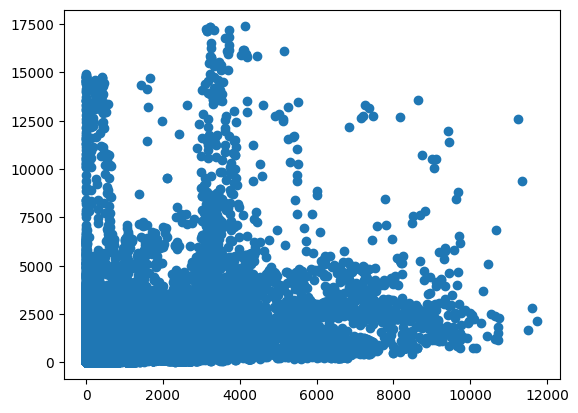

In [10]:
plt.scatter(x = df_state["on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses"], y = df_state["inpatient_beds_used_covid"])

In [11]:
# Removing these 3 columns as they are moderate and positively correlated  with inpatient beds used for covid
df_state = df_state.drop(columns = ["on_hand_supply_therapeutic_a_casirivimab_imdevimab_courses", "on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses", 
               "on_hand_supply_therapeutic_b_bamlanivimab_courses"])


In [12]:
df_state.columns

Index(['state', 'date', 'critical_staffing_shortage_today_yes',
       'critical_staffing_shortage_today_no',
       'critical_staffing_shortage_today_not_reported',
       'critical_staffing_shortage_anticipated_within_week_yes',
       'critical_staffing_shortage_anticipated_within_week_no',
       'critical_staffing_shortage_anticipated_within_week_not_reported',
       'hospital_onset_covid', 'hospital_onset_covid_coverage',
       'inpatient_beds', 'inpatient_beds_coverage', 'inpatient_beds_used',
       'inpatient_beds_used_coverage', 'inpatient_beds_used_covid',
       'inpatient_beds_used_covid_coverage', 'inpatient_beds_utilization',
       'inpatient_beds_utilization_coverage',
       'inpatient_beds_utilization_numerator',
       'inpatient_beds_utilization_denominator',
       'percent_of_inpatients_with_covid',
       'percent_of_inpatients_with_covid_coverage',
       'percent_of_inpatients_with_covid_numerator',
       'percent_of_inpatients_with_covid_denominator',
    

In [ ]:
#Explains the same information as the percentage thats caculated with these numerators and denominators.
df_state = df_state.drop(columns = ["inpatient_beds_utilization_coverage", 
                        "inpatient_beds_utilization",
                        "percent_of_inpatients_with_covid",
                        "percent_of_inpatients_with_covid_coverage",
                        "inpatient_bed_covid_utilization",
                        "inpatient_bed_covid_utilization_coverage",
                         ])

In [14]:
df_state.columns

Index(['state', 'date', 'critical_staffing_shortage_today_yes',
       'critical_staffing_shortage_today_no',
       'critical_staffing_shortage_today_not_reported',
       'critical_staffing_shortage_anticipated_within_week_yes',
       'critical_staffing_shortage_anticipated_within_week_no',
       'critical_staffing_shortage_anticipated_within_week_not_reported',
       'hospital_onset_covid', 'hospital_onset_covid_coverage',
       'inpatient_beds', 'inpatient_beds_coverage', 'inpatient_beds_used',
       'inpatient_beds_used_coverage', 'inpatient_beds_used_covid',
       'inpatient_beds_used_covid_coverage',
       'inpatient_beds_utilization_numerator',
       'inpatient_beds_utilization_denominator',
       'percent_of_inpatients_with_covid_numerator',
       'percent_of_inpatients_with_covid_denominator',
       'inpatient_bed_covid_utilization_numerator',
       'inpatient_bed_covid_utilization_denominator', 'deaths_covid',
       'deaths_covid_coverage', 'icu_patients_confirm

# Feature Engineering

In [15]:
# Coverage per state (row wise)
df_state["coverage_per_state"] = df_state["critical_staffing_shortage_today_yes"] + df_state["critical_staffing_shortage_today_no"] + df_state["critical_staffing_shortage_today_not_reported"]


In [16]:
# Normalized deaths per hostpital from covid 
df_state["deaths_covid"] = df_state["deaths_covid"] / (df_state["deaths_covid_coverage"] / df_state["coverage_per_state"])

# Staffing shortage ratio
df_state["state_staffing_shortage_ratio"] = df_state["critical_staffing_shortage_today_yes"] / (df_state["critical_staffing_shortage_today_yes"] + df_state["critical_staffing_shortage_today_no"])

# Reporting completeness
df_state["state_staffing_reporting_completeness"] = (df_state["critical_staffing_shortage_today_yes"] + df_state["critical_staffing_shortage_today_no"]) / (
    df_state["coverage_per_state"]
)

# Reporting for next week (staffing shortage) ratio
df_state["state_staffing_shortage_anticipation_ratio"] = df_state["critical_staffing_shortage_anticipated_within_week_yes"] / (df_state["critical_staffing_shortage_anticipated_within_week_yes"] + df_state["critical_staffing_shortage_anticipated_within_week_no"])

# Reporting for next week (staffing shortage) completeness
df_state["state_staffing_shortage_anticipation_completeness"] = (df_state["critical_staffing_shortage_anticipated_within_week_yes"] + df_state["critical_staffing_shortage_anticipated_within_week_no"]) / (
    df_state["critical_staffing_shortage_anticipated_within_week_yes"] + df_state["critical_staffing_shortage_anticipated_within_week_no"] + df_state["critical_staffing_shortage_anticipated_within_week_not_reported"] )

In [17]:
df_state = df_state.drop(columns = ["deaths_covid_coverage", "deaths_covid", "critical_staffing_shortage_anticipated_within_week_yes", "critical_staffing_shortage_anticipated_within_week_no",
                         "critical_staffing_shortage_anticipated_within_week_not_reported"])

In [18]:
# Normalized deaths per hostpital from covid 
df_state["hospital_onset_covid"] = df_state["hospital_onset_covid"] / (df_state["hospital_onset_covid_coverage"] / df_state["coverage_per_state"])

# Normalized beds total per hospital 
df_state["inpatient_beds"] = df_state["inpatient_beds"] / (df_state["inpatient_beds_coverage"] / df_state["coverage_per_state"])

# Normalized beds used per hospital 
df_state["inpatient_beds_used"] = df_state["inpatient_beds_used"] / (df_state["inpatient_beds_used_coverage"] / df_state["coverage_per_state"])

# Normalize inpatients beds used from covidper hospital 
df_state["inpatient_beds_used_covid"] = df_state["inpatient_beds_used_covid"] / (df_state["inpatient_beds_used_covid_coverage"] / df_state["coverage_per_state"])

# just influenza
df_state["icu_patients_confirmed_influenza"] = df_state["icu_patients_confirmed_influenza"] / (df_state["icu_patients_confirmed_influenza_coverage"] / df_state["coverage_per_state"])

#normalize count of total icu patients
df_state["total_patients_hospitalized_confirmed_influenza"] = df_state["total_patients_hospitalized_confirmed_influenza"] / (df_state["total_patients_hospitalized_confirmed_influenza_coverage"] / df_state["coverage_per_state"])

#Normalized count for covid plus influenza patients
df_state["total_patients_hospitalized_confirmed_influenza_and_covid"] = df_state["total_patients_hospitalized_confirmed_influenza_and_covid"] / (df_state["total_patients_hospitalized_confirmed_influenza_and_covid_coverage"] / df_state["coverage_per_state"])


df_state = df_state.drop(columns = ["hospital_onset_covid_coverage", "inpatient_beds_coverage", "inpatient_beds_used_coverage", "inpatient_beds_used_covid_coverage",
"icu_patients_confirmed_influenza_coverage", "total_patients_hospitalized_confirmed_influenza_coverage", "total_patients_hospitalized_confirmed_influenza_and_covid_coverage"])

## Final column drop of correlated variables

In [19]:
df_state.columns

Index(['state', 'date', 'critical_staffing_shortage_today_yes',
       'critical_staffing_shortage_today_no',
       'critical_staffing_shortage_today_not_reported', 'hospital_onset_covid',
       'inpatient_beds', 'inpatient_beds_used', 'inpatient_beds_used_covid',
       'inpatient_beds_utilization_numerator',
       'inpatient_beds_utilization_denominator',
       'percent_of_inpatients_with_covid_numerator',
       'percent_of_inpatients_with_covid_denominator',
       'inpatient_bed_covid_utilization_numerator',
       'inpatient_bed_covid_utilization_denominator',
       'icu_patients_confirmed_influenza',
       'total_patients_hospitalized_confirmed_influenza',
       'total_patients_hospitalized_confirmed_influenza_and_covid',
       'coverage_per_state', 'state_staffing_shortage_ratio',
       'state_staffing_reporting_completeness',
       'state_staffing_shortage_anticipation_ratio',
       'state_staffing_shortage_anticipation_completeness'],
      dtype='object')

In [20]:
df_state = df_state.drop(columns = ["inpatient_beds_utilization_numerator",
"inpatient_beds_utilization_denominator",
'percent_of_inpatients_with_covid_numerator',
'percent_of_inpatients_with_covid_denominator',
'inpatient_bed_covid_utilization_numerator',
'inpatient_bed_covid_utilization_denominator', "critical_staffing_shortage_today_yes",
"critical_staffing_shortage_today_no", "critical_staffing_shortage_today_not_reported"]
       )


### Final List of Variables

In [21]:
df_state.columns

Index(['state', 'date', 'hospital_onset_covid', 'inpatient_beds',
       'inpatient_beds_used', 'inpatient_beds_used_covid',
       'icu_patients_confirmed_influenza',
       'total_patients_hospitalized_confirmed_influenza',
       'total_patients_hospitalized_confirmed_influenza_and_covid',
       'coverage_per_state', 'state_staffing_shortage_ratio',
       'state_staffing_reporting_completeness',
       'state_staffing_shortage_anticipation_ratio',
       'state_staffing_shortage_anticipation_completeness'],
      dtype='object')

# Simple EDA

### Correlation heatmap

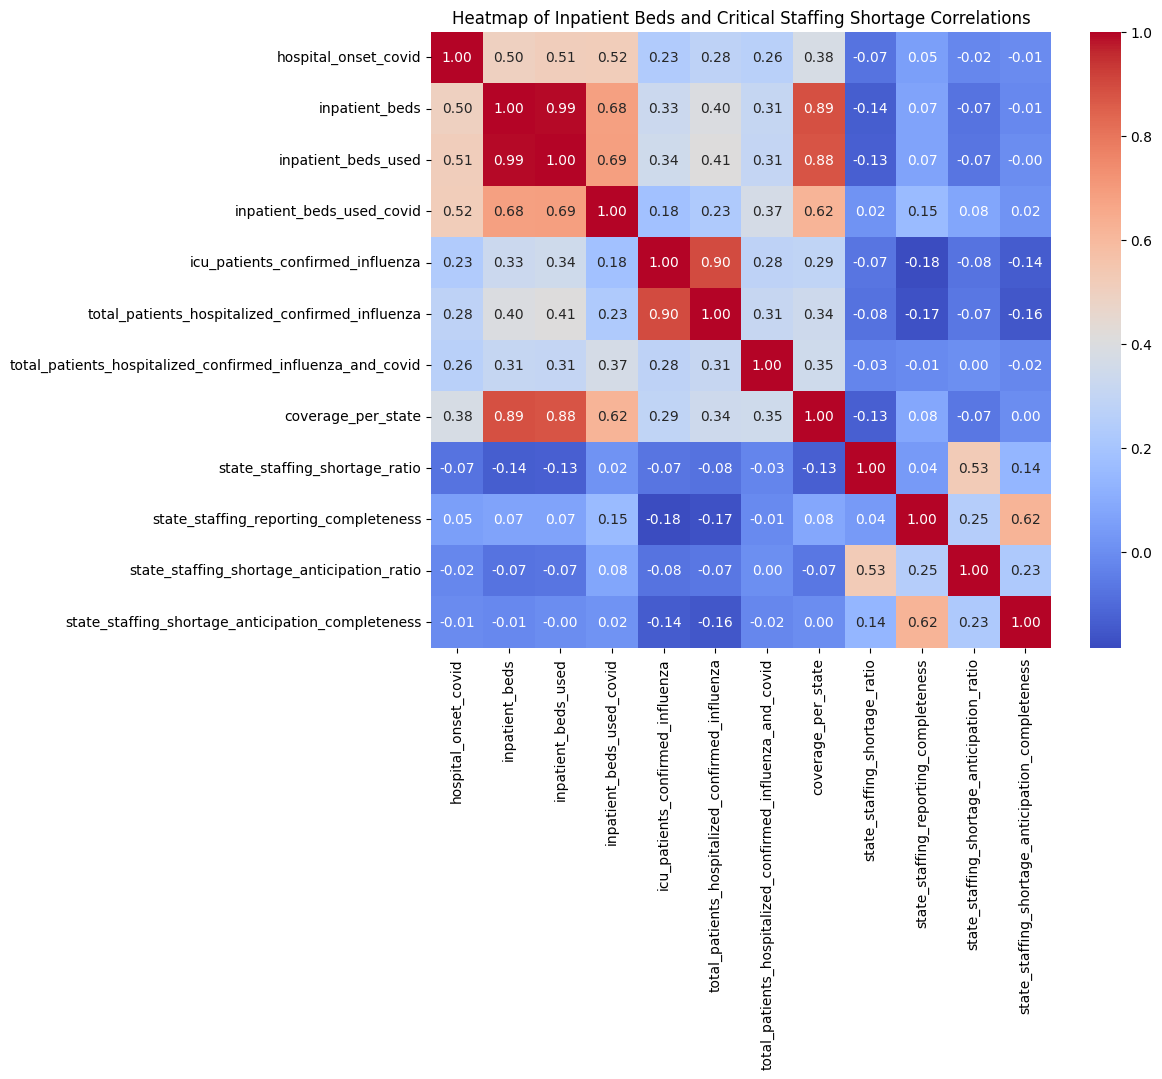

In [25]:
corr_mat = (df_state.loc[:, ~df_state.columns.isin(["state", "date"])]).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap of Inpatient Beds and Critical Staffing Shortage Correlations")
plt.show()

create proportion variable denoting percentage of people with influenza in the ICU

In [31]:
df_state["ICU_patients_influenza_prop"] = df_state["icu_patients_confirmed_influenza"] / df_state["total_patients_hospitalized_confirmed_influenza"]

df_state = df_state.drop(columns = ["icu_patients_confirmed_influenza", "total_patients_hospitalized_confirmed_influenza", "inpatient_beds_used_covid"])

In [33]:
df_state.columns

Index(['state', 'date', 'hospital_onset_covid', 'inpatient_beds',
       'inpatient_beds_used',
       'total_patients_hospitalized_confirmed_influenza_and_covid',
       'coverage_per_state', 'state_staffing_shortage_ratio',
       'state_staffing_reporting_completeness',
       'state_staffing_shortage_anticipation_ratio',
       'state_staffing_shortage_anticipation_completeness',
       'ICU_patients_influenza_prop'],
      dtype='object')